# Идентификация пород собак
Этот ноутбук содержит базовое решение для соревнования Dog Breed Identification.

In [4]:
import os
import shutil
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import kagglehub
import kagglehub.cache
import kagglehub.handle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import timm
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
import matplotlib


SEED = 42
EPOCHS = 10
BATCH_SIZE = 32
NUM_WORKERS = 2
LEARNING_RATE_BACKBONE = 1e-5
LEARNING_RATE_CLASSIFIER = 1e-4
WEIGHT_DECAY = 1e-2
PCT_START = 0.2
TEST_SIZE = 0.2
IMAGE_SIZE = 384
NUM_CLASSES = 120
MODEL_NAME = "vit_base_patch16_384"
DATASET_NAME = "dog-breed-identification"
INTERACTIVE = True

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not INTERACTIVE:
    matplotlib.use("Agg")

## 1. Загрузка и настройка датасета

In [5]:
handle = kagglehub.handle.parse_competition_handle(DATASET_NAME)
cache_path = Path(kagglehub.cache.get_cached_path(handle))
marker_path = Path(kagglehub.cache._get_competitions_completion_marker_filepath(handle))

if cache_path.exists() and marker_path.exists():
    path = cache_path
else:
    from kagglehub.auth import get_username
    username = get_username()
    if username is None:
        print("Вы не авторизованы в Kaggle. Запуск процесса авторизации...")
        kagglehub.login()
        username = get_username()
        if username is None:
            raise RuntimeError("Пожалуйста, введите ваш API-токен Kaggle в интерактивном окне выше и запустите эту ячейку снова.")
    print(f"Вы авторизованы как пользователь: {username}")
    path = kagglehub.competition_download(DATASET_NAME)

DATA_DIR = Path(path)
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
LABELS_CSV = DATA_DIR / "labels.csv"
SAMPLE_SUBMISSION_CSV = DATA_DIR / "sample_submission.csv"

Вы авторизованы как пользователь: feytox


100%|██████████| 691M/691M [00:39<00:00, 18.5MB/s]

Extracting files...


## 2. Разведочный анализ данных (EDA)
Анализ распределения классов и проверка размеров изображений.

Размер датасета: (10222, 2)
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever
Минимум изображений на породу: 66
Максимум изображений на породу: 126


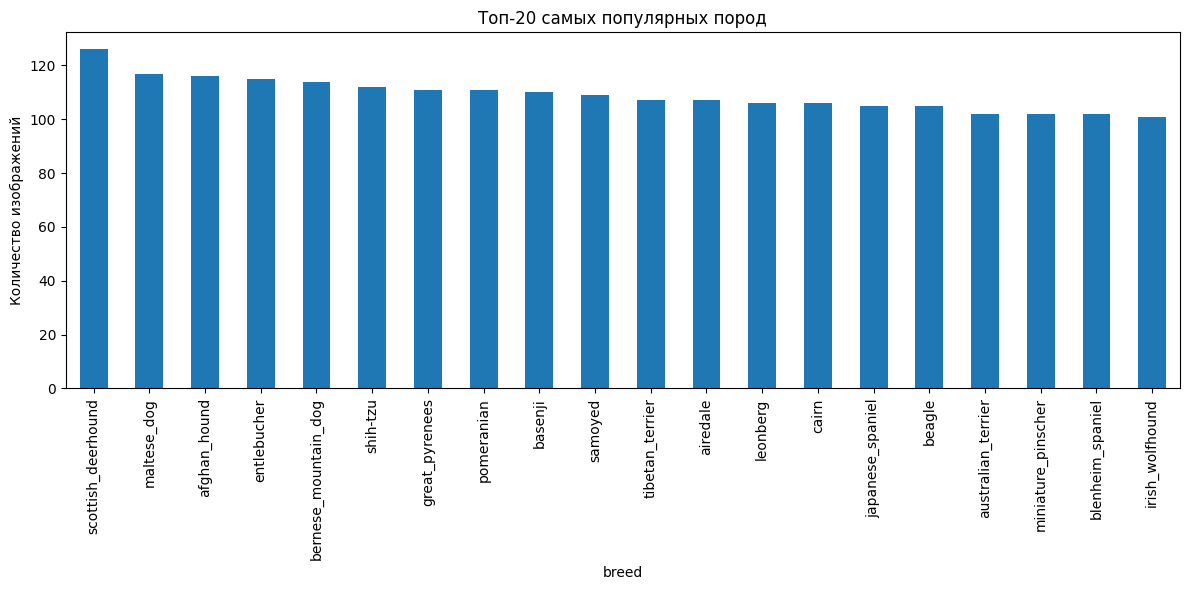

Пример изображения: 000bec180eb18c7604dcecc8fe0dba07.jpg, размер: (500, 375), каналы: RGB


In [6]:
df = pd.read_csv(LABELS_CSV)
print(f"Размер датасета: {df.shape}")
print(df.head())

counts = df["breed"].value_counts()
print(f"Минимум изображений на породу: {counts.min()}")
print(f"Максимум изображений на породу: {counts.max()}")

plt.figure(figsize=(12, 6))
counts.head(20).plot(kind="bar")
plt.title("Топ-20 самых популярных пород")
plt.ylabel("Количество изображений")
plt.tight_layout()
plt.show()

img_id = df.iloc[0]["id"]
img_path = TRAIN_DIR / f"{img_id}.jpg"
img = Image.open(img_path)
print(f"Пример изображения: {img_id}.jpg, размер: {img.size}, каналы: {img.mode}")

## 3. Разделение выборки
Разделение данных на обучающую и валидационную выборки с использованием стратификации для сохранения соотношения классов.

In [7]:
breeds = sorted(df["breed"].unique())
breed_to_idx = {b: i for i, b in enumerate(breeds)}
idx_to_breed = {i: b for i, b in enumerate(breeds)}
df["label"] = df["breed"].map(breed_to_idx)

train_df, val_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=SEED
)

print(f"Размер обучающей выборки: {train_df.shape[0]}")
print(f"Размер валидационной выборки: {val_df.shape[0]}")

Размер обучающей выборки: 8177
Размер валидационной выборки: 2045


## 4. Класс датасета и загрузчики данных
Определение класса `DogDataset` для загрузки изображений и применение аугментаций для обучения.

In [8]:
class DogDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.ids = df["id"].values
        self.labels = df["label"].values if "label" in df.columns else None

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_name = f"{self.ids[idx]}.jpg"
        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.labels is not None:
            return image, self.labels[idx]
        return image, self.ids[idx]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.3, value="random")
])

val_transforms = transforms.Compose([
    transforms.Resize((int(IMAGE_SIZE * 256 / 224), int(IMAGE_SIZE * 256 / 224))),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = DogDataset(train_df, TRAIN_DIR, transform=train_transforms)
val_dataset = DogDataset(val_df, TRAIN_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

## 5. Инициализация предобученной модели ResNet-34
Загрузка ResNet-34 с весами ImageNet и изменение финального полносвязного слоя для классификации 120 пород собак.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

print(f"Модель загружена и перемещена на: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

Модель загружена и перемещена на: cuda


## 6. Функция потерь и оптимизатор

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

backbone_params = []
classifier_params = []
for name, param in model.named_parameters():
    if "classifier" in name or "head" in name:
        classifier_params.append(param)
    else:
        backbone_params.append(param)

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": LEARNING_RATE_BACKBONE},
    {"params": classifier_params, "lr": LEARNING_RATE_CLASSIFIER}
], weight_decay=WEIGHT_DECAY)

scaler = GradScaler("cuda")

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LEARNING_RATE_BACKBONE * 10, LEARNING_RATE_CLASSIFIER * 10],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=PCT_START
)

## 7. Цикл обучения и валидации

In [11]:
best_loss = float("inf")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{EPOCHS} [Train]")
    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix({
            "Loss": f"{running_loss / total:.4f}",
            "Acc": f"{running_correct / total:.4f}"
        })

    epoch_train_loss = running_loss / total
    epoch_train_acc = running_correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_progress_bar = tqdm(val_loader, desc=f"Эпоха {epoch+1}/{EPOCHS} [Val]")
    with torch.no_grad():
        for images, labels in val_progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

            val_progress_bar.set_postfix({
                "Loss": f"{val_loss / val_total:.4f}",
                "Acc": f"{val_correct / val_total:.4f}"
            })

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    print(f"Эпоха {epoch+1}/{EPOCHS}")
    print(f"Train LogLoss: {epoch_train_loss:.4f} - Train Accuracy: {epoch_train_acc:.4f}")
    print(f"Val LogLoss: {epoch_val_loss:.4f} - Val Accuracy: {epoch_val_acc:.4f}")

    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Сохранена лучшая модель.")

Эпоха 1/10 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

/tmp/ipykernel_2183/1704926044.py:23: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Эпоха 1/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Эпоха 1/10
Train LogLoss: 3.2399 - Train Accuracy: 0.3847
Val LogLoss: 1.6042 - Val Accuracy: 0.7438
Сохранена лучшая модель.


Эпоха 2/10 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

...

Эпоха 9/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Эпоха 9/10
Train LogLoss: 0.9052 - Train Accuracy: 0.9884
Val LogLoss: 1.3213 - Val Accuracy: 0.8445
Сохранена лучшая модель.


Эпоха 10/10 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Эпоха 10/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Эпоха 10/10
Train LogLoss: 0.8943 - Train Accuracy: 0.9908
Val LogLoss: 1.3252 - Val Accuracy: 0.8425


## 8. Качественная оценка модели

### 8.1 Получение предсказаний на валидационной выборке

In [12]:
from sklearn.metrics import classification_report, log_loss

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast("cuda"):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

### 8.2 Расчет метрик качества (Accuracy и Log Loss)

In [13]:
val_acc = np.mean(all_preds == all_labels)
val_logloss = log_loss(all_labels, all_probs, labels=np.arange(NUM_CLASSES))

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Log Loss: {val_logloss:.4f}")

Validation Accuracy: 0.8445
Validation Log Loss: 0.7213


### 8.3 Топ-10 легких и сложных пород собак по F1-Score

In [14]:
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=breeds,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
breed_metrics = report_df.iloc[:-3].copy()

top_10_easy = breed_metrics.sort_values(by="f1-score", ascending=False).head(10)
print("Топ-10 пород с наивысшим F1-Score:")
display(top_10_easy[["precision", "recall", "f1-score"]])

top_10_hard = breed_metrics.sort_values(by="f1-score", ascending=True).head(10)
print("Топ-10 пород с наименьшим F1-Score:")
display(top_10_hard[["precision", "recall", "f1-score"]])

Топ-10 пород с наивысшим F1-Score:


,precision,recall,f1-score
african_hunting_dog,1.000000,1.000000,1.000000
doberman,1.000000,1.000000,1.000000
dandie_dinmont,1.000000,1.000000,1.000000
komondor,1.000000,1.000000,1.000000
pug,1.000000,1.000000,1.000000
sussex_spaniel,1.000000,1.000000,1.000000
basenji,0.956522,1.000000,0.977778
beagle,0.954545,1.000000,0.976744
leonberg,0.954545,1.000000,0.976744
japanese_spaniel,1.000000,0.952381,0.975610


Топ-10 пород с наименьшим F1-Score:


,precision,recall,f1-score
kelpie,0.636364,0.411765,0.500000
eskimo_dog,0.545455,0.461538,0.500000
siberian_husky,0.500000,0.526316,0.512821
american_staffordshire_terrier,0.500000,0.533333,0.516129
miniature_poodle,0.636364,0.437500,0.518519
collie,0.700000,0.411765,0.518519
walker_hound,0.700000,0.500000,0.583333
australian_terrier,0.833333,0.476190,0.606061
staffordshire_bullterrier,0.578947,0.687500,0.628571
shih-tzu,0.722222,0.565217,0.634146


### 8.4 Наиболее частые ошибки классификации (Confusion Matrix)

In [15]:
confusion_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_labels, all_preds):
    confusion_matrix[t, p] += 1

confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and confusion_matrix[i, j] > 0:
            confused_pairs.append((idx_to_breed[i], idx_to_breed[j], confusion_matrix[i, j]))

confused_pairs = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

confused_pairs_df = pd.DataFrame(confused_pairs[:10], columns=["Истинная порода", "Предсказанная порода", "Количество ошибок"])
print("Топ-10 наиболее часто путаемых пар пород:")
display(confused_pairs_df)

Топ-10 наиболее часто путаемых пар пород:


,Истинная порода,Предсказанная порода,Количество ошибок
0,american_staffordshire_terrier,staffordshire_bullterrier,6
1,cardigan,pembroke,5
2,eskimo_dog,siberian_husky,5
3,malamute,siberian_husky,5
4,shih-tzu,lhasa,5
5,australian_terrier,silky_terrier,4
6,collie,border_collie,4
7,collie,shetland_sheepdog,4
8,kuvasz,great_pyrenees,4
9,miniature_poodle,toy_poodle,4


### 8.5 Визуализация правильных и ошибочных предсказаний

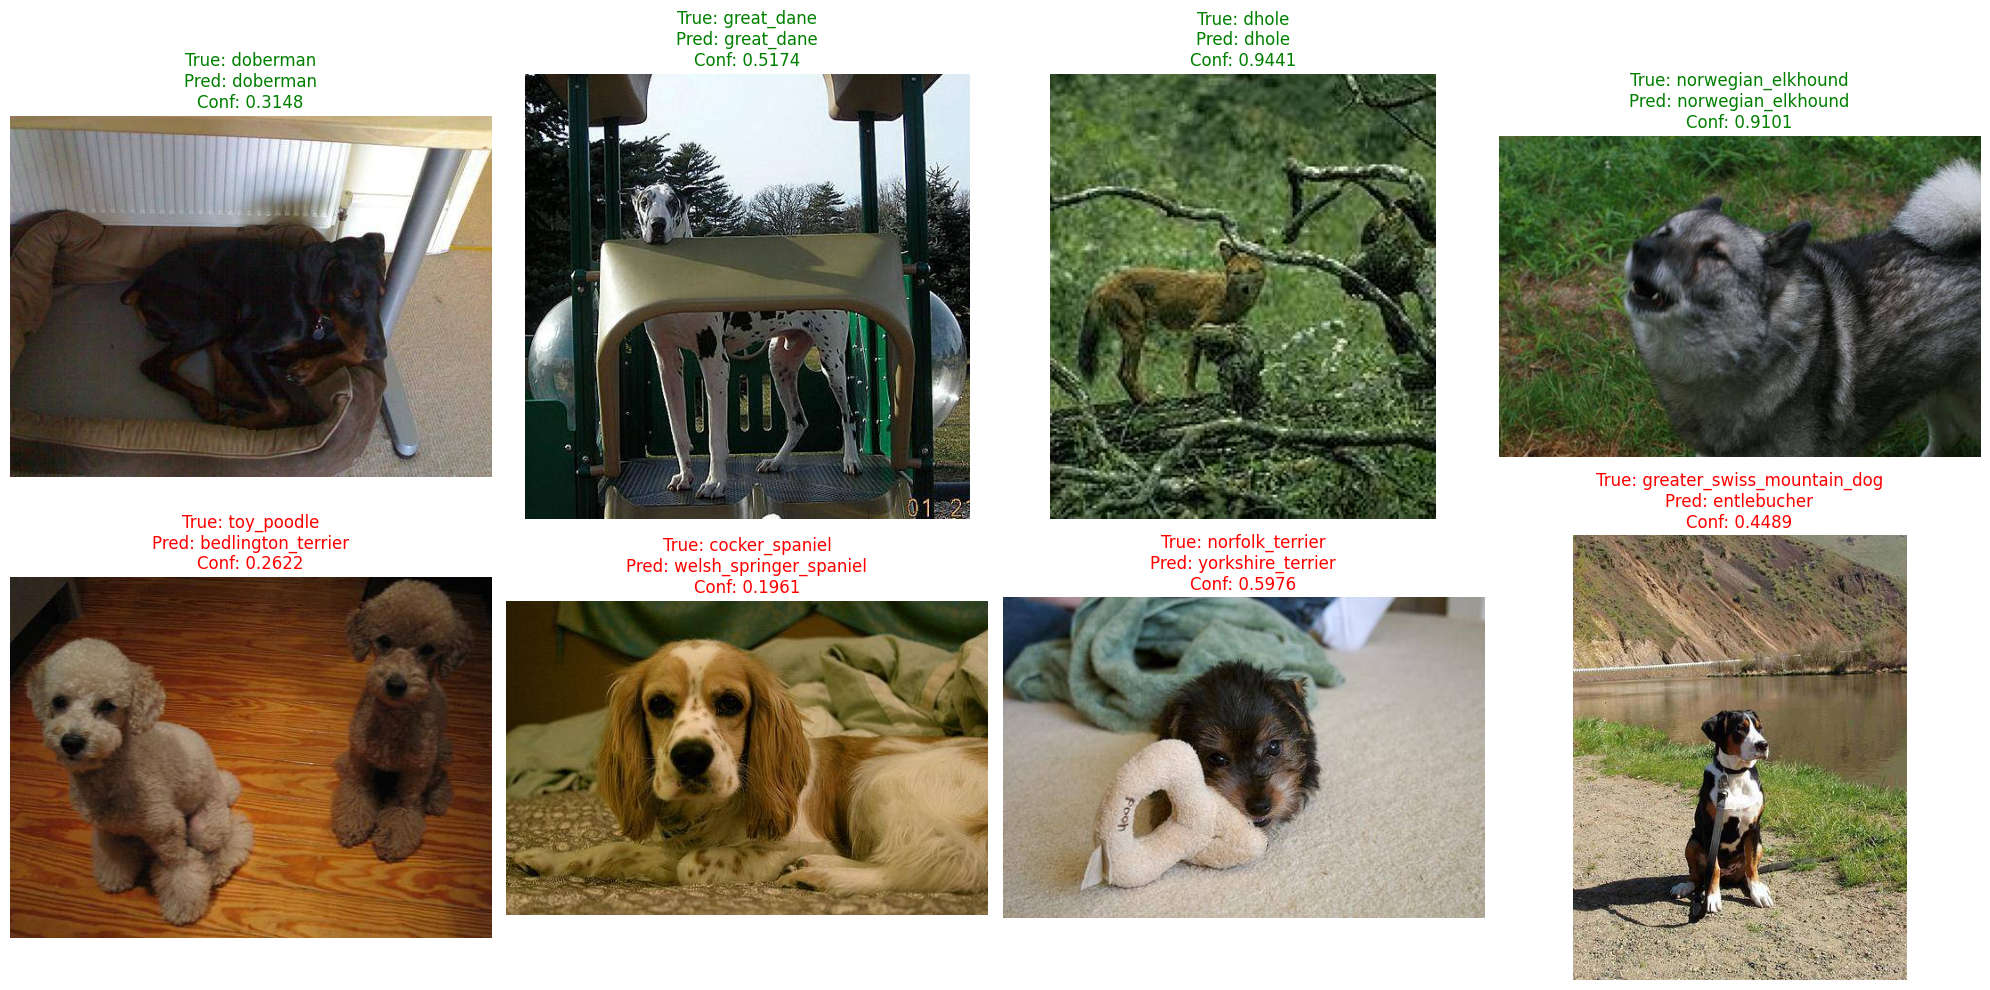

In [16]:
val_df_with_preds = val_df.copy()
val_df_with_preds["predicted_label"] = all_preds
val_df_with_preds["predicted_breed"] = val_df_with_preds["predicted_label"].map(idx_to_breed)
val_df_with_preds["confidence"] = [probs[p] for probs, p in zip(all_probs, all_preds)]
val_df_with_preds["correct"] = val_df_with_preds["label"] == val_df_with_preds["predicted_label"]

correct_samples = val_df_with_preds[val_df_with_preds["correct"]].sample(n=min(4, len(val_df_with_preds[val_df_with_preds["correct"]])), random_state=SEED)
incorrect_samples = val_df_with_preds[~val_df_with_preds["correct"]].sample(n=min(4, len(val_df_with_preds[~val_df_with_preds["correct"]])), random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (_, row) in enumerate(correct_samples.iterrows()):
    img_path = TRAIN_DIR / f"{row['id']}.jpg"
    img = Image.open(img_path)
    ax = axes[0, i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {row['breed']}\nPred: {row['predicted_breed']}\nConf: {row['confidence']:.4f}", color="green")

for i, (_, row) in enumerate(incorrect_samples.iterrows()):
    img_path = TRAIN_DIR / f"{row['id']}.jpg"
    img = Image.open(img_path)
    ax = axes[1, i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {row['breed']}\nPred: {row['predicted_breed']}\nConf: {row['confidence']:.4f}", color="red")

plt.tight_layout()
plt.show()

## 9. Инференс на тестовой выборке и генерация сабмишна

In [17]:
test_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
test_dataset = DogDataset(test_df, TEST_DIR, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

preds_list = []

with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="Инференс"):
        images = images.to(device, non_blocking=True)

        with autocast("cuda"):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

        preds_list.append(probs.cpu().numpy())

preds_array = np.vstack(preds_list)

submission = pd.DataFrame(preds_array, columns=breeds)
submission.insert(0, "id", test_df["id"].values)
submission.to_csv("submission.csv", index=False)

print("Файл submission.csv успешно сохранен.")

Инференс:   0%|          | 0/324 [00:00<?, ?it/s]

Файл submission.csv успешно сохранен.


## 10. Проверка файла сабмишна

In [18]:
sub = pd.read_csv("submission.csv")
print(f"Формат сабмишна: {sub.shape}")
print(sub.head())
print(f"Есть ли пропущенные значения: {sub.isnull().any().any()}")

row_sums = sub.iloc[:, 1:].sum(axis=1)
print(f"Минимальная сумма строки: {row_sums.min():.4f}")
print(f"Максимальная сумма строки: {row_sums.max():.4f}")

Формат сабмишна: (10357, 121)
                                 id  affenpinscher  afghan_hound  \
0  000621fb3cbb32d8935728e48679680e       0.000240      0.001327   
1  00102ee9d8eb90812350685311fe5890       0.000485      0.000254   
2  0012a730dfa437f5f3613fb75efcd4ce       0.000836      0.002816   
3  001510bc8570bbeee98c8d80c8a95ec1       0.005478      0.002975   
4  001a5f3114548acdefa3d4da05474c2e       0.012243      0.002925   

   african_hunting_dog  airedale  american_staffordshire_terrier  appenzeller  \
0             0.001384  0.003156                        0.000679     0.000426   
1             0.001147  0.000802                        0.002071     0.000652   
2             0.001460  0.003375                        0.000572     0.002322   
3             0.000391  0.002557                        0.012260     0.000861   
4             0.000842  0.000422                        0.002112     0.000342   

   australian_terrier   basenji    basset  ...  toy_poodle  toy_terrier  \